In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

In [3]:
clean_data = pd.read_csv('Clean_Dataset.csv', index_col=0)

print(f"Shape  : {clean_data.shape[0]:,} lignes × {clean_data.shape[1]} colones")

Shape  : 300,153 lignes × 11 colones


In [4]:
clean_data.dtypes

airline              object
flight               object
source_city          object
departure_time       object
stops                object
arrival_time         object
destination_city     object
class                object
duration            float64
days_left             int64
price                 int64
dtype: object

In [5]:
clean_data.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [6]:
clean_data.isna().sum()

airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

In [7]:
clean_data[["duration", "days_left", "price"]].describe().round(2)

,duration,days_left,price
count,300153.00,300153.00,300153.00
mean,12.22,26.00,20889.66
std,7.19,13.56,22697.77
min,0.83,1.00,1105.00
25%,6.83,15.00,4783.00
50%,11.25,26.00,7425.00
75%,16.17,38.00,42521.00
max,49.83,49.00,123071.00


In [8]:
"""
duration min 0.83 h OK, max 49.83 h hmmmm
# price min 1 105 INR, max 123 071 INR hmmmmm
"""

'\nduration min 0.83 h OK, max 49.83 h hmmmm\n# price min 1 105 INR, max 123 071 INR hmmmmm\n'

In [9]:

for col in ["airline", "source_city", "destination_city","departure_time", "arrival_time", "stops", "class"]:
    print('\n')
    print(clean_data[col].value_counts())






airline
Vistara      127859
Air_India     80892
Indigo        43120
GO_FIRST      23173
AirAsia       16098
SpiceJet       9011
Name: count, dtype: int64


source_city
Delhi        61343
Mumbai       60896
Bangalore    52061
Kolkata      46347
Hyderabad    40806
Chennai      38700
Name: count, dtype: int64


destination_city
Mumbai       59097
Delhi        57360
Bangalore    51068
Kolkata      49534
Hyderabad    42726
Chennai      40368
Name: count, dtype: int64


departure_time
Morning          71146
Early_Morning    66790
Evening          65102
Night            48015
Afternoon        47794
Late_Night        1306
Name: count, dtype: int64


arrival_time
Night            91538
Evening          78323
Morning          62735
Afternoon        38139
Early_Morning    15417
Late_Night       14001
Name: count, dtype: int64


stops
one            250863
zero            36004
two_or_more     13286
Name: count, dtype: int64


class
Economy     206666
Business     93487
Name: count, dtype: int64

In [10]:
n_dup = clean_data.duplicated().sum()
n_dup

0

In [11]:
clean_data.drop(columns=["flight"])

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...
300148,Vistara,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,Vistara,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,Vistara,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,Vistara,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


In [12]:
clean_data_encoding = clean_data.copy()
clean_data_encoding["class"].value_counts()

class
Economy     206666
Business     93487
Name: count, dtype: int64

In [13]:
class_encoding = {"Economy": 0, "Business": 1}
clean_data_encoding["class"] = clean_data_encoding["class"].map(class_encoding)
clean_data_encoding["class"].value_counts()

class
0    206666
1     93487
Name: count, dtype: int64

In [14]:
clean_data_encoding["stops"].value_counts()

stops
one            250863
zero            36004
two_or_more     13286
Name: count, dtype: int64

In [15]:
stops_encoding = {"zero": 0, "one": 1, "two_or_more": 2}
clean_data_encoding["stops"] = clean_data_encoding["stops"].map(stops_encoding)
clean_data_encoding["stops"].value_counts()

stops
1    250863
0     36004
2     13286
Name: count, dtype: int64

In [16]:
clean_data_encoding["departure_time"].value_counts()

departure_time
Morning          71146
Early_Morning    66790
Evening          65102
Night            48015
Afternoon        47794
Late_Night        1306
Name: count, dtype: int64

In [17]:
time_encoding = {
    "Early_Morning": 0,
    "Morning"      : 1,
    "Afternoon"    : 2,
    "Evening"      : 3,
    "Night"        : 4,
    "Late_Night"   : 5,
}
clean_data_encoding["departure_time"] = clean_data_encoding["departure_time"].map(time_encoding)
clean_data_encoding["arrival_time"]   = clean_data_encoding["arrival_time"].map(time_encoding)
clean_data_encoding["departure_time"].value_counts().sort_index()

departure_time
0    66790
1    71146
2    47794
3    65102
4    48015
5     1306
Name: count, dtype: int64

In [18]:
clean_data_encoding = pd.get_dummies(clean_data_encoding,columns=["airline", "source_city", "destination_city"],dtype=int)
print(f"Shape apres one-hot: {clean_data_encoding.shape}")

Shape apres one-hot: (300153, 26)


In [19]:
clean_data_encoding

,flight,departure_time,stops,arrival_time,class,duration,days_left,price,airline_AirAsia,airline_Air_India,...,source_city_Delhi,source_city_Hyderabad,source_city_Kolkata,source_city_Mumbai,destination_city_Bangalore,destination_city_Chennai,destination_city_Delhi,destination_city_Hyderabad,destination_city_Kolkata,destination_city_Mumbai
0,SG-8709,3,0,4,0,2.17,1,5953,0,0,...,1,0,0,0,0,0,0,0,0,1
1,SG-8157,0,0,1,0,2.33,1,5953,0,0,...,1,0,0,0,0,0,0,0,0,1
2,I5-764,0,0,0,0,2.17,1,5956,1,0,...,1,0,0,0,0,0,0,0,0,1
3,UK-995,1,0,2,0,2.25,1,5955,0,0,...,1,0,0,0,0,0,0,0,0,1
4,UK-963,1,0,1,0,2.33,1,5955,0,0,...,1,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
300148,UK-822,1,1,3,1,10.08,49,69265,0,0,...,0,0,0,0,0,0,0,1,0,0
300149,UK-826,2,1,4,1,10.42,49,77105,0,0,...,0,0,0,0,0,0,0,1,0,0
300150,UK-832,0,1,4,1,13.83,49,79099,0,0,...,0,0,0,0,0,0,0,1,0,0
300151,UK-828,0,1,3,1,10.00,49,81585,0,0,...,0,0,0,0,0,0,0,1,0,0


In [20]:
intervalles = [0, 3, 21, 35, 49]
categories = ["Dernière minute", "Achat court terme", "Achat anticipé", "Achat très anticipé"]
clean_data["delai_reservation"] = pd.cut(clean_data["days_left"], bins=intervalles, labels=categories)

clean_data_encoding["delai_reservation"] = pd.Categorical(clean_data["delai_reservation"], categories=categories, ordered=True).codes

clean_data["delai_reservation"].value_counts().sort_index()

delai_reservation
Dernière minute        32113
Achat court terme      87956
Achat anticipé         90777
Achat très anticipé    89307
Name: count, dtype: int64

In [21]:
duree_intervalles = [0, 3, 8, 20, 50]
duree_categories  = ["Court ( < 3h )", "Moyen ( 3-8h )", "Long ( 8-20h )", "Très long ( > 20h )"]

clean_data["duree_vol"] = pd.cut(clean_data["duration"], bins=duree_intervalles, labels=duree_categories)

clean_data_encoding["duree_vol"] = pd.Categorical(clean_data["duree_vol"], categories=duree_categories, ordered=True).codes


clean_data["duree_vol"].value_counts().sort_index()

duree_vol
Court ( < 3h )          35811
Moyen ( 3-8h )          60763
Long ( 8-20h )         152824
Très long ( > 20h )     50755
Name: count, dtype: int64

In [22]:
clean_data["prix_par_heure"] = clean_data["price"] / clean_data["duration"]
clean_data_encoding["prix_par_heure"] = clean_data_encoding["price"] / clean_data_encoding["duration"]

clean_data["est_direct"] = (clean_data["stops"] == "zero").astype(int)
clean_data_encoding["est_direct"] = (clean_data_encoding["stops"] == 0).astype(int)

# on peut ajouter une colone pour determiner si lo vol fait son depart dans une periode de pointe

In [23]:
print(f"Dimensions finales du jeu de données encodé : {clean_data_encoding.shape}")

Dimensions finales du jeu de données encodé : (300153, 30)


In [45]:
clean_data_encoding.delai_reservation

0         0
1         0
2         0
3         0
4         0
         ..
300148    3
300149    3
300150    3
300151    3
300152    3
Name: delai_reservation, Length: 300153, dtype: int8

In [25]:
clean_data.columns

Index(['airline', 'flight', 'source_city', 'departure_time', 'stops',
       'arrival_time', 'destination_city', 'class', 'duration', 'days_left',
       'price', 'delai_reservation', 'duree_vol', 'prix_par_heure',
       'est_direct'],
      dtype='object')

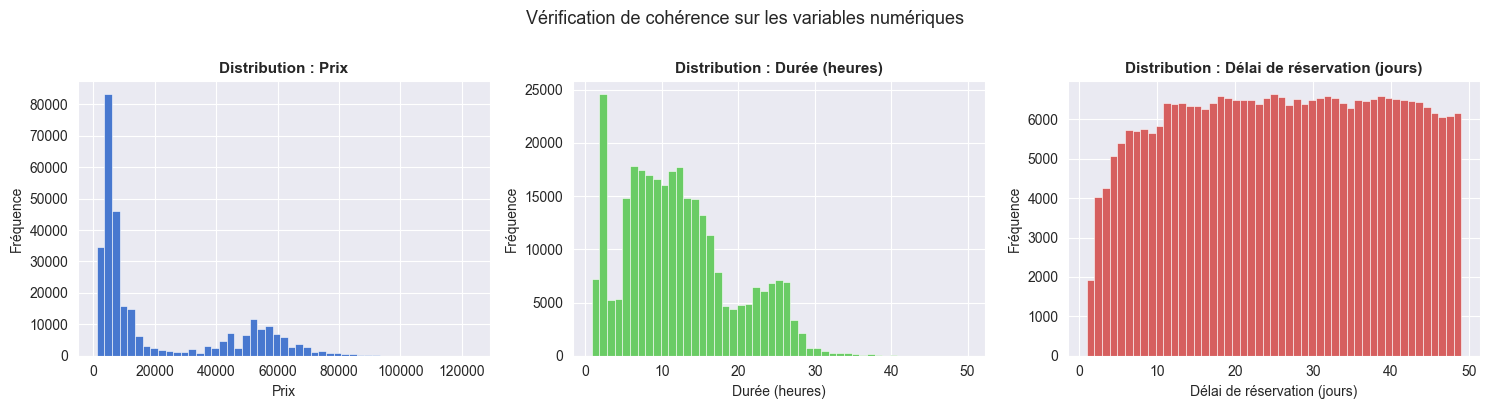

In [26]:
traduction = {
    "price": "Prix",
    "duration": "Durée (heures)",
    "days_left": "Délai de réservation (jours)"
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, color in zip(axes,
                          ["price", "duration", "days_left"],
                          ["#4878CF", "#6ACC65", "#D65F5F"]):

    ax.hist(clean_data[col], bins=49, color=color, edgecolor="white", linewidth=0.4)

    nom_francais = traduction[col]

    ax.set_title(f"Distribution : {nom_francais}", fontsize=11, fontweight="bold")
    ax.set_xlabel(nom_francais)
    ax.set_ylabel("Fréquence")

# Titre général en français
fig.suptitle("Vérification de cohérence sur les variables numériques", fontsize=13, y=1.01)

plt.tight_layout()
plt.show()

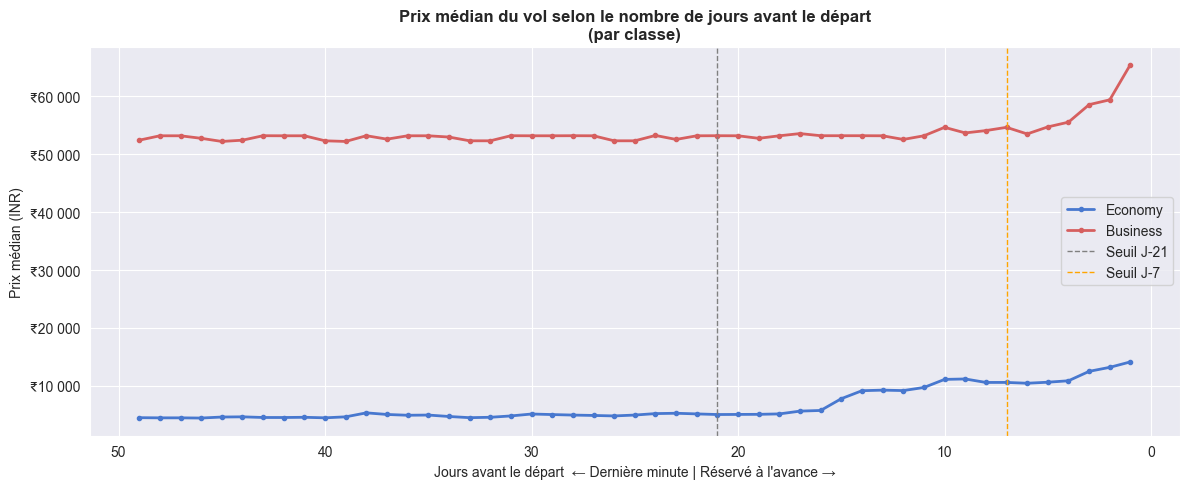

In [31]:
pivot = clean_data.groupby(["days_left", "class"])["price"].median().reset_index()

fig, ax = plt.subplots(figsize=(12, 5))

for cls, color in [("Economy", "#4878CF"), ("Business", "#D65F5F")]:
    sub = pivot[pivot["class"] == cls].sort_values("days_left")
    ax.plot(sub["days_left"], sub["price"],
            label=cls, color=color, lw=2, marker="o", ms=3)

# Seuils critiques (lignes verticales)
ax.axvline(x=21, color="gray", ls="--", lw=1, label="Seuil J-21")
ax.axvline(x=7,  color="orange", ls="--", lw=1, label="Seuil J-7")


ax.set_title("Prix médian du vol selon le nombre de jours avant le départ\n(par classe)",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Prix médian (INR)")

# Formatage de l'axe des Y (avec un espace pour les milliers)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"₹{x:,.0f}".replace(",", " ")))

# Inversion de l'axe X : la gauche = dernière minute, la droite = réservé très tôt
ax.invert_xaxis()
ax.set_xlabel("Jours avant le départ  ← Dernière minute | Réservé à l'avance →", fontsize=10)

ax.legend()
plt.tight_layout()
plt.show()

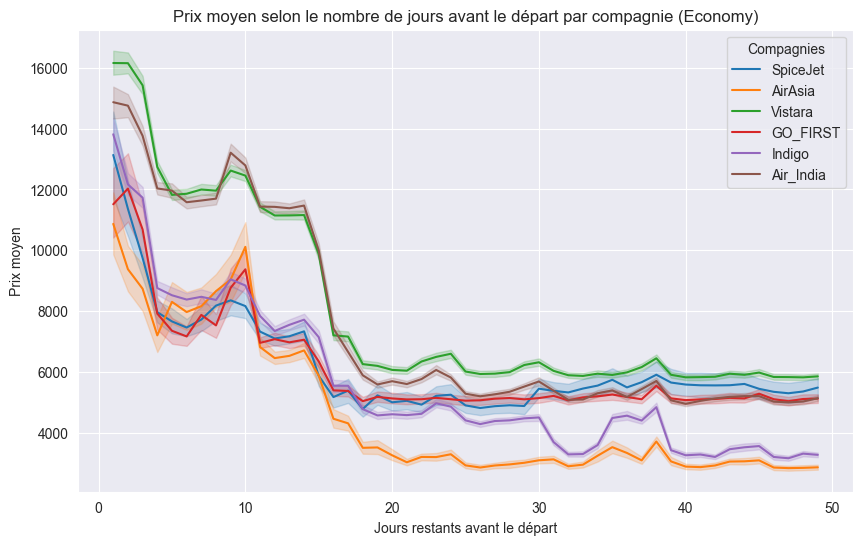

In [64]:
plt.figure(figsize=(10, 6)) # Augmenté un peu pour la lisibilité avec la légende

sns.lineplot(
    x="days_left",
    y="price",
    hue="airline", # <--- Permet de séparer par compagnie avec des couleurs différentes
    data=clean_data.loc[clean_data["class"] == "Economy"],
    estimator="mean"
)

plt.title("Prix moyen selon le nombre de jours avant le départ par compagnie (Economy)")
plt.xlabel("Jours restants avant le départ")
plt.ylabel("Prix moyen")
plt.legend(title="Compagnies") # Ajoute un titre à la légende
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_40704\1403592216.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x="airline", y="price", order=order,
C:\Users\user\AppData\Local\Temp\ipykernel_40704\1403592216.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x="airline", y="price", order=order,


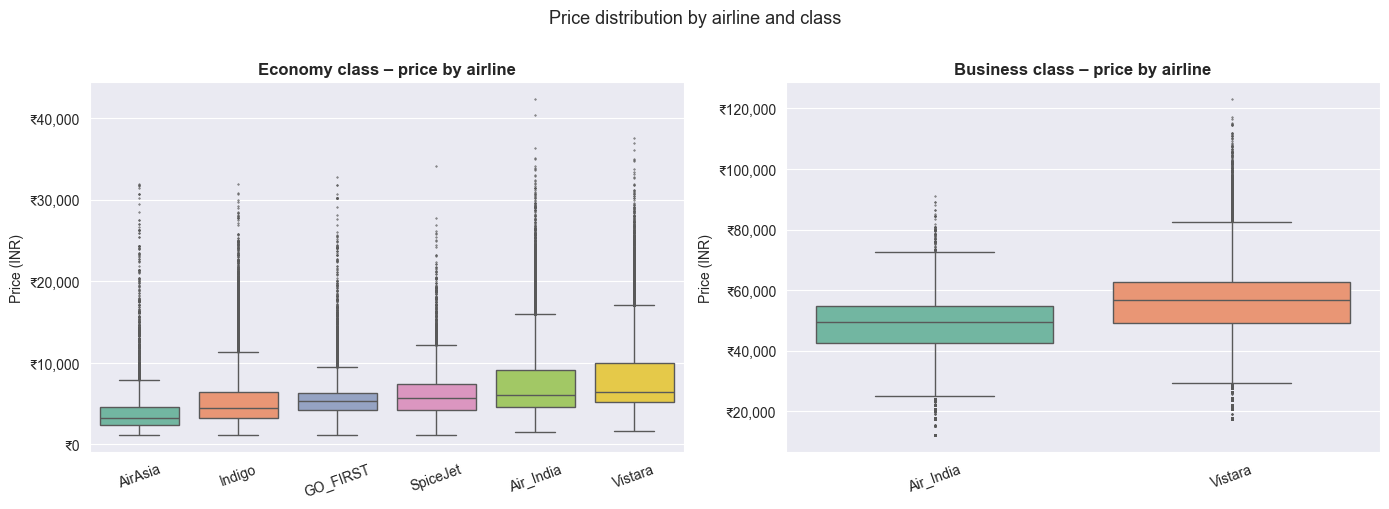

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
for ax, cls in zip(axes, ["Economy", "Business"]):
    sub = clean_data[clean_data["class"] == cls]
    order = sub.groupby("airline")["price"].median().sort_values().index
    sns.boxplot(data=sub, x="airline", y="price", order=order,
                palette="Set2", ax=ax, flierprops=dict(marker=".", ms=1))
    ax.set_title(f"{cls} class – price by airline", fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Price (INR)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"₹{x:,.0f}"))
    ax.tick_params(axis="x", rotation=20)

plt.suptitle("Price distribution by airline and class", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


[]

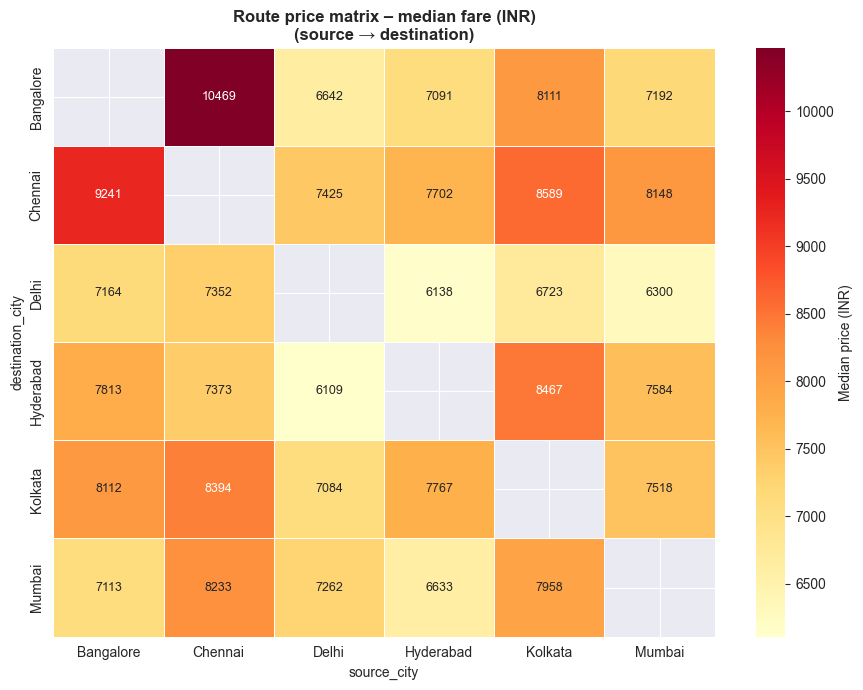

In [49]:
route_matrix = clean_data.groupby(["destination_city", "source_city"])["price"].median().unstack()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(route_matrix, annot=True, fmt=".0f", cmap="YlOrRd",
            linewidths=0.5, ax=ax,
            annot_kws={"size": 9},
            cbar_kws={"label": "Median price (INR)"})
ax.set_title("Route price matrix – median fare (INR)\n(source → destination)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("source_city")
ax.set_ylabel("destination_city")
plt.tight_layout()
plt.plot()

In [34]:
clean_data.columns

Index(['airline', 'flight', 'source_city', 'departure_time', 'stops',
       'arrival_time', 'destination_city', 'class', 'duration', 'days_left',
       'price', 'delai_reservation', 'duree_vol', 'prix_par_heure',
       'est_direct'],
      dtype='object')

C:\Users\user\AppData\Local\Temp\ipykernel_40704\2845755454.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=sub, x="delai_reservation", y="price",
C:\Users\user\AppData\Local\Temp\ipykernel_40704\2845755454.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=sub, x="delai_reservation", y="price",


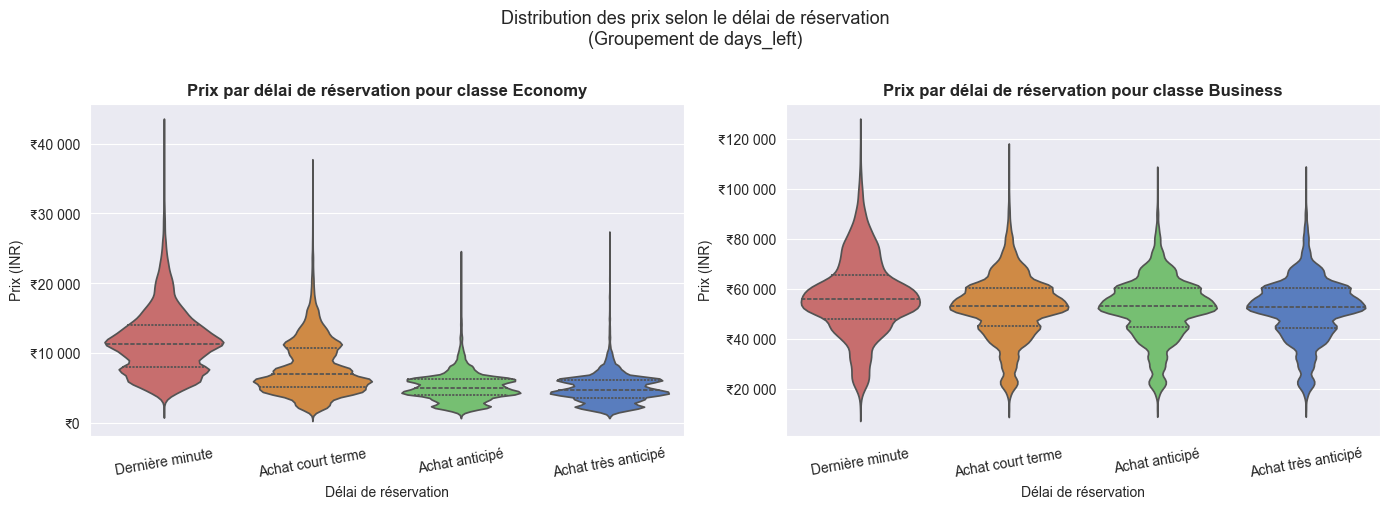

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

ordre_categories = ["Dernière minute", "Achat court terme", "Achat anticipé", "Achat très anticipé"]

for ax, cls in zip(axes, ["Economy", "Business"]):
    sub = clean_data[clean_data["class"] == cls]

    sns.violinplot(data=sub, x="delai_reservation", y="price",
                   order=ordre_categories,
                   palette=["#D65F5F", "#E68A2E", "#6ACC65", "#4878CF"],
                   inner="quartile", ax=ax)

    ax.set_title(f"Prix par délai de réservation pour classe {cls}", fontweight="bold")
    ax.set_xlabel("Délai de réservation")
    ax.set_ylabel("Prix (INR)")

    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"₹{x:,.0f}".replace(",", " ")))
    ax.tick_params(axis="x", rotation=10)

plt.suptitle("Distribution des prix selon le délai de réservation\n(Groupement de days_left)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


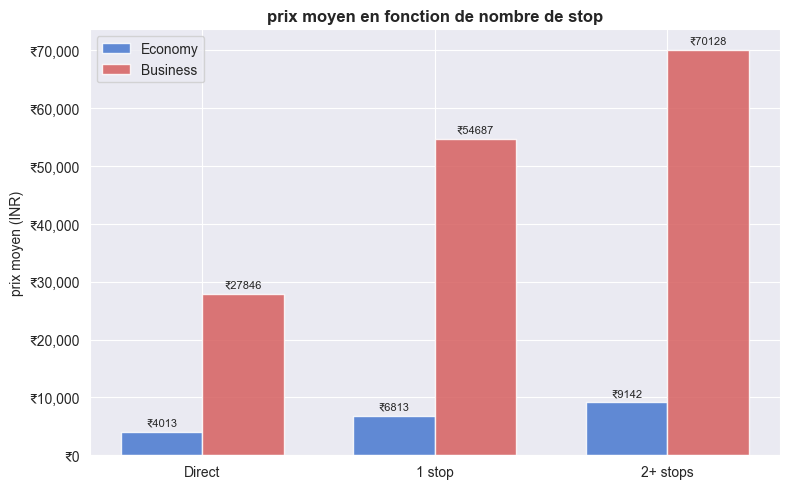

In [42]:
stops_class = clean_data.groupby(["stops", "class"])["price"].mean().reset_index()
stops_order = ["zero", "one", "two_or_more"]

fig, ax = plt.subplots(figsize=(8, 5))
width = 0.35
x = np.arange(len(stops_order))
for i, (cls, color) in enumerate([("Economy", "#4878CF"), ("Business", "#D65F5F")]):
    vals = [stops_class[(stops_class["stops"] == s) &
                        (stops_class["class"] == cls)]["price"].values[0]
            for s in stops_order]
    bars = ax.bar(x + i * width - width / 2, vals, width, label=cls, color=color, alpha=0.85)
    ax.bar_label(bars, fmt="₹%.0f", padding=3, fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(["Direct", "1 stop", "2+ stops"])
ax.set_ylabel("prix moyen (INR)")
ax.set_title("prix moyen en fonction de nombre de stop", fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"₹{x:,.0f}"))
ax.legend()
plt.tight_layout()

plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_40704\3615660446.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=clean_data[clean_data["class"] == "Economy"],


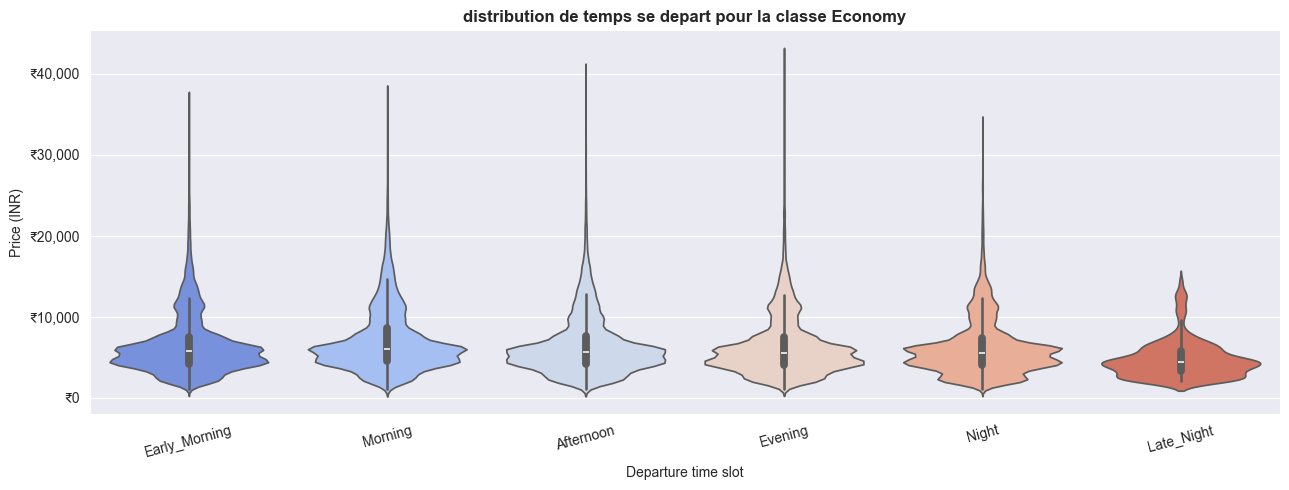

In [52]:
time_order = ["Early_Morning", "Morning", "Afternoon", "Evening", "Night", "Late_Night"]
fig, ax = plt.subplots(figsize=(13, 5))
sns.violinplot(data=clean_data[clean_data["class"] == "Economy"],
               x="departure_time", y="price",
               order=time_order,
               palette="coolwarm", inner="box", ax=ax)
ax.set_title("distribution de temps se depart pour la classe Economy", fontweight="bold")
ax.set_xlabel("periode de depart")
ax.set_ylabel("Price (INR)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"₹{x:,.0f}"))
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

In [54]:
clean_data_encoding.columns

Index(['flight', 'departure_time', 'stops', 'arrival_time', 'class',
       'duration', 'days_left', 'price', 'airline_AirAsia',
       'airline_Air_India', 'airline_GO_FIRST', 'airline_Indigo',
       'airline_SpiceJet', 'airline_Vistara', 'source_city_Bangalore',
       'source_city_Chennai', 'source_city_Delhi', 'source_city_Hyderabad',
       'source_city_Kolkata', 'source_city_Mumbai',
       'destination_city_Bangalore', 'destination_city_Chennai',
       'destination_city_Delhi', 'destination_city_Hyderabad',
       'destination_city_Kolkata', 'destination_city_Mumbai',
       'delai_reservation', 'duree_vol', 'prix_par_heure', 'est_direct'],
      dtype='object')

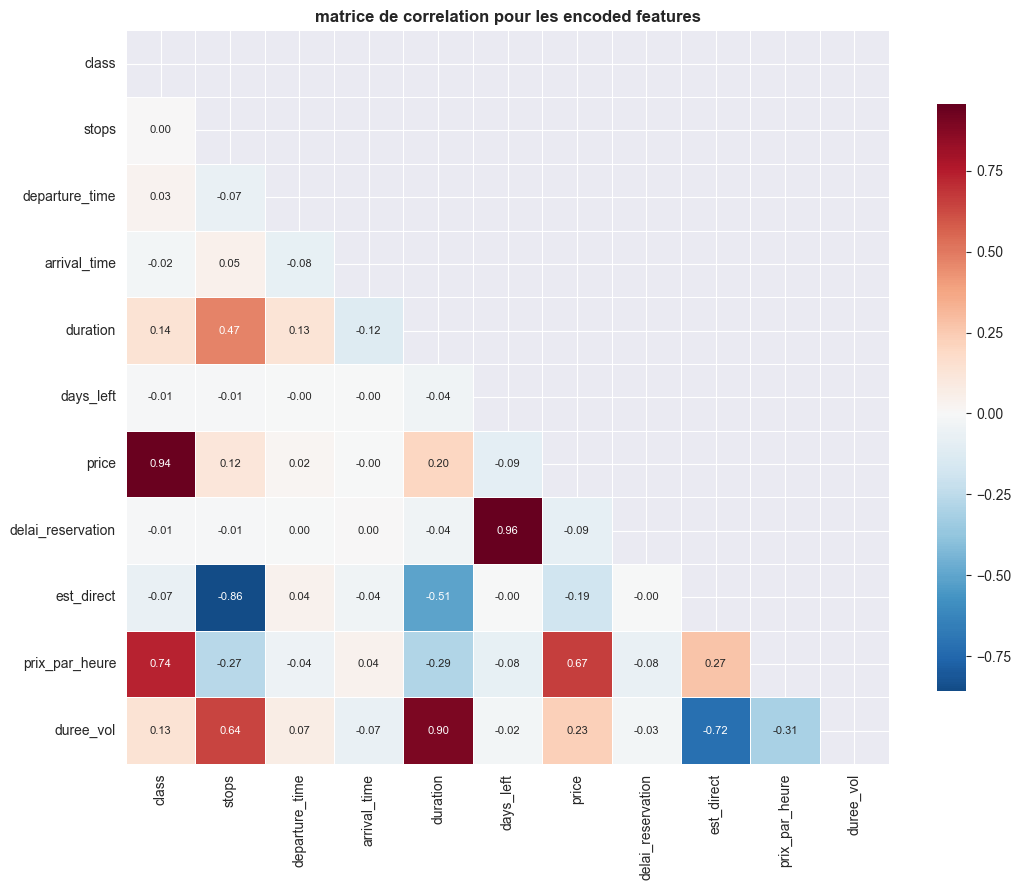

In [58]:
core_cols = ["class", "stops", "departure_time", "arrival_time",
             "duration", "days_left", "price",
             "delai_reservation", "est_direct", "prix_par_heure",
             "duree_vol"]
corr = clean_data_encoding[core_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, linewidths=0.4, ax=ax,
            annot_kws={"size": 8},
            cbar_kws={"shrink": 0.8})
ax.set_title("matrice de correlation pour les encoded features", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_40704\530489975.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["airline", "delai_reservation"])["price"]


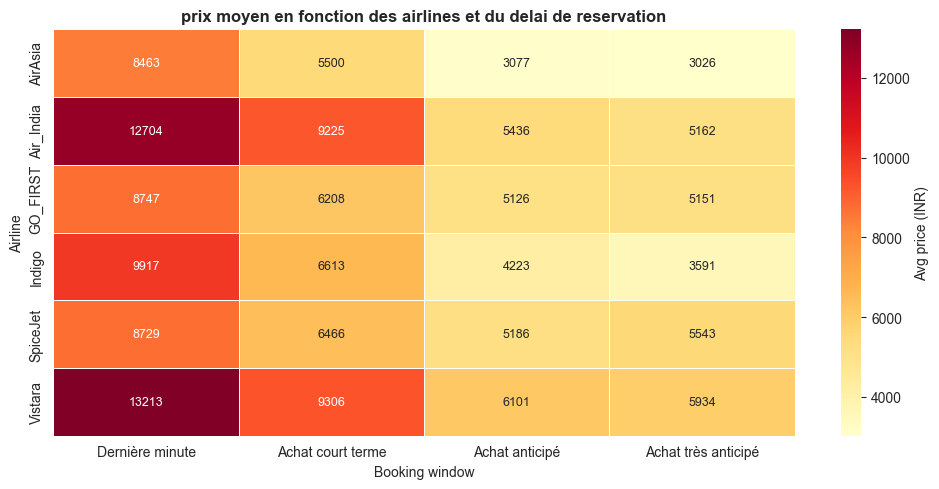

In [97]:
airline_window = (clean_data[clean_data["class"] == "Economy"]
                  .groupby(["airline", "delai_reservation"])["price"]
                  .mean()
                  .unstack()
                  .reindex(columns=ordre_categories))

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(airline_window, annot=True, fmt=".0f", cmap="YlOrRd",
            linewidths=0.5, ax=ax,
            annot_kws={"size": 9},
            cbar_kws={"label": "Avg price (INR)"})
ax.set_title("prix moyen en fonction des airlines et du delai de reservation", fontsize=12, fontweight="bold")
ax.set_xlabel("Booking window")
ax.set_ylabel("Airline")
plt.tight_layout()
plt.show()

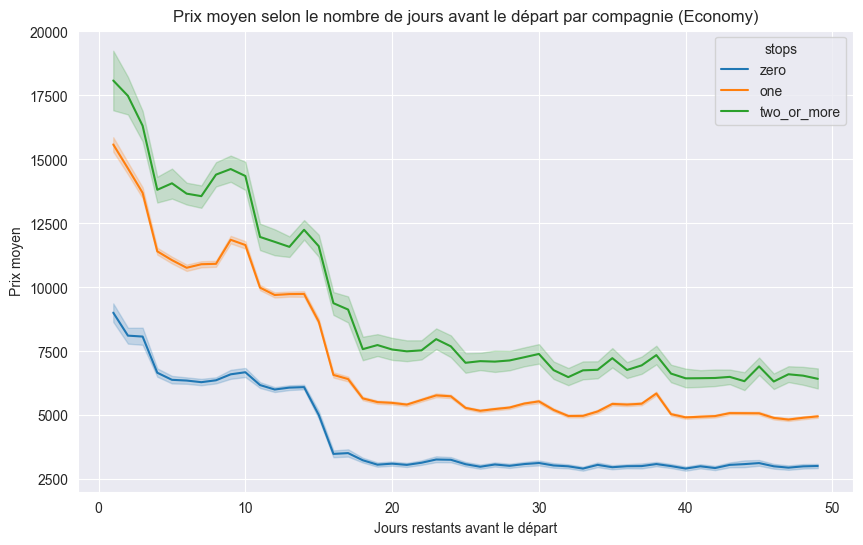

In [92]:
plt.figure(figsize=(10, 6)) # Augmenté un peu pour la lisibilité avec la légende

sns.lineplot(
    x="days_left",
    y="price",
    hue="stops",
    data=clean_data.loc[clean_data["class"] == "Economy"],
    estimator="mean"
)

plt.title("Prix moyen selon le nombre de jours avant le départ par compagnie (Economy)")
plt.xlabel("Jours restants avant le départ")
plt.ylabel("Prix moyen")
plt.legend(title="stops") # Ajoute un titre à la légende
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_40704\1529306935.py:23: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_routes_num = df_routes.replace(mapping_categories)


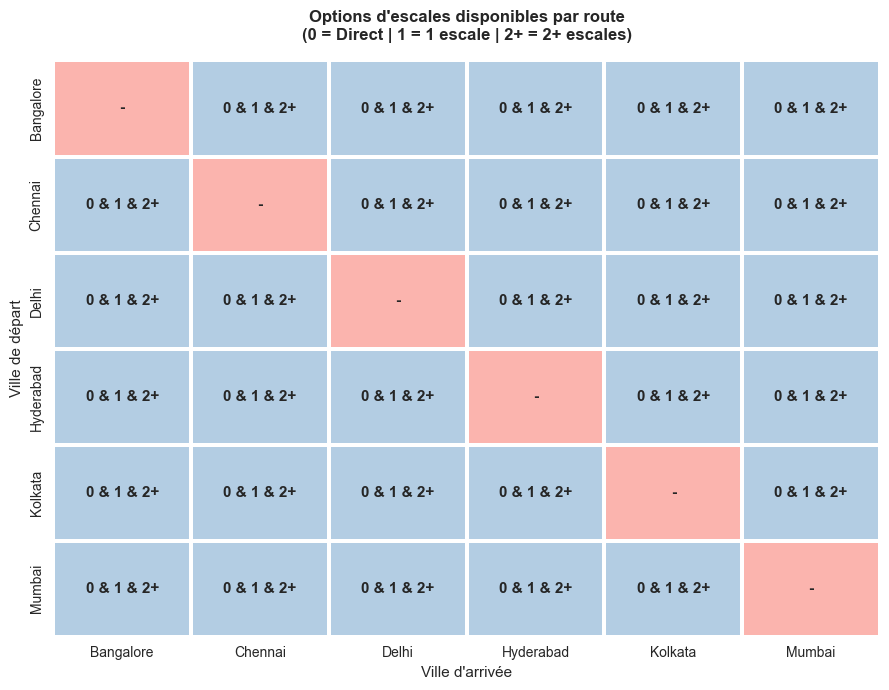

In [82]:
# 1. Dictionnaire pour transformer les chaînes en formats courts
mapping_stops = {
    "zero": "0",
    "one": "1",
    "two_or_more": "2+"
}

def lister_options_courtes(series):
    options = series.dropna().unique()
    # On applique le format court (0, 1, 2+)
    options_courtes = [mapping_stops[opt] for opt in options if opt in mapping_stops]
    if not options_courtes:
        return "-" # Pour les cas sans vols (ex: la diagonale Delhi -> Delhi)
    # Tri pour s'assurer d'avoir toujours l'ordre "0 & 1 & 2+"
    return " & ".join(sorted(options_courtes))

# 2. Agrégation par route et pivotage
df_routes = clean_data.groupby(['source_city', 'destination_city'])['stops'].agg(lister_options_courtes).unstack(fill_value="-")

# 3. Transformation des combinaisons uniques en IDs numériques pour la coloration
categories_uniques = sorted(np.unique(df_routes.values))
mapping_categories = {cat: i for i, cat in enumerate(categories_uniques)}
df_routes_num = df_routes.replace(mapping_categories)

# 4. Dessin de la matrice
plt.figure(figsize=(9, 7))
# Palette de couleurs discrètes adaptée au nombre de combinaisons réelles
cmap = sns.color_palette("Pastel1", len(categories_uniques))

ax = sns.heatmap(df_routes_num, annot=df_routes.values, fmt="", cmap=cmap, cbar=False,
                 linewidths=1.5, linecolor="white",
                 annot_kws={"size": 11, "weight": "bold"})

plt.title("Options d'escales disponibles par route\n(0 = Direct | 1 = 1 escale | 2+ = 2+ escales)",
          fontsize=12, fontweight='bold', pad=15)
plt.xlabel("Ville d'arrivée", fontsize=11)
plt.ylabel("Ville de départ", fontsize=11)
plt.tick_params(axis='both', which='major', labelsize=10)
plt.tight_layout()
plt.show()

In [83]:
clean_data.columns

Index(['airline', 'flight', 'source_city', 'departure_time', 'stops',
       'arrival_time', 'destination_city', 'class', 'duration', 'days_left',
       'price', 'delai_reservation', 'duree_vol', 'prix_par_heure',
       'est_direct'],
      dtype='object')

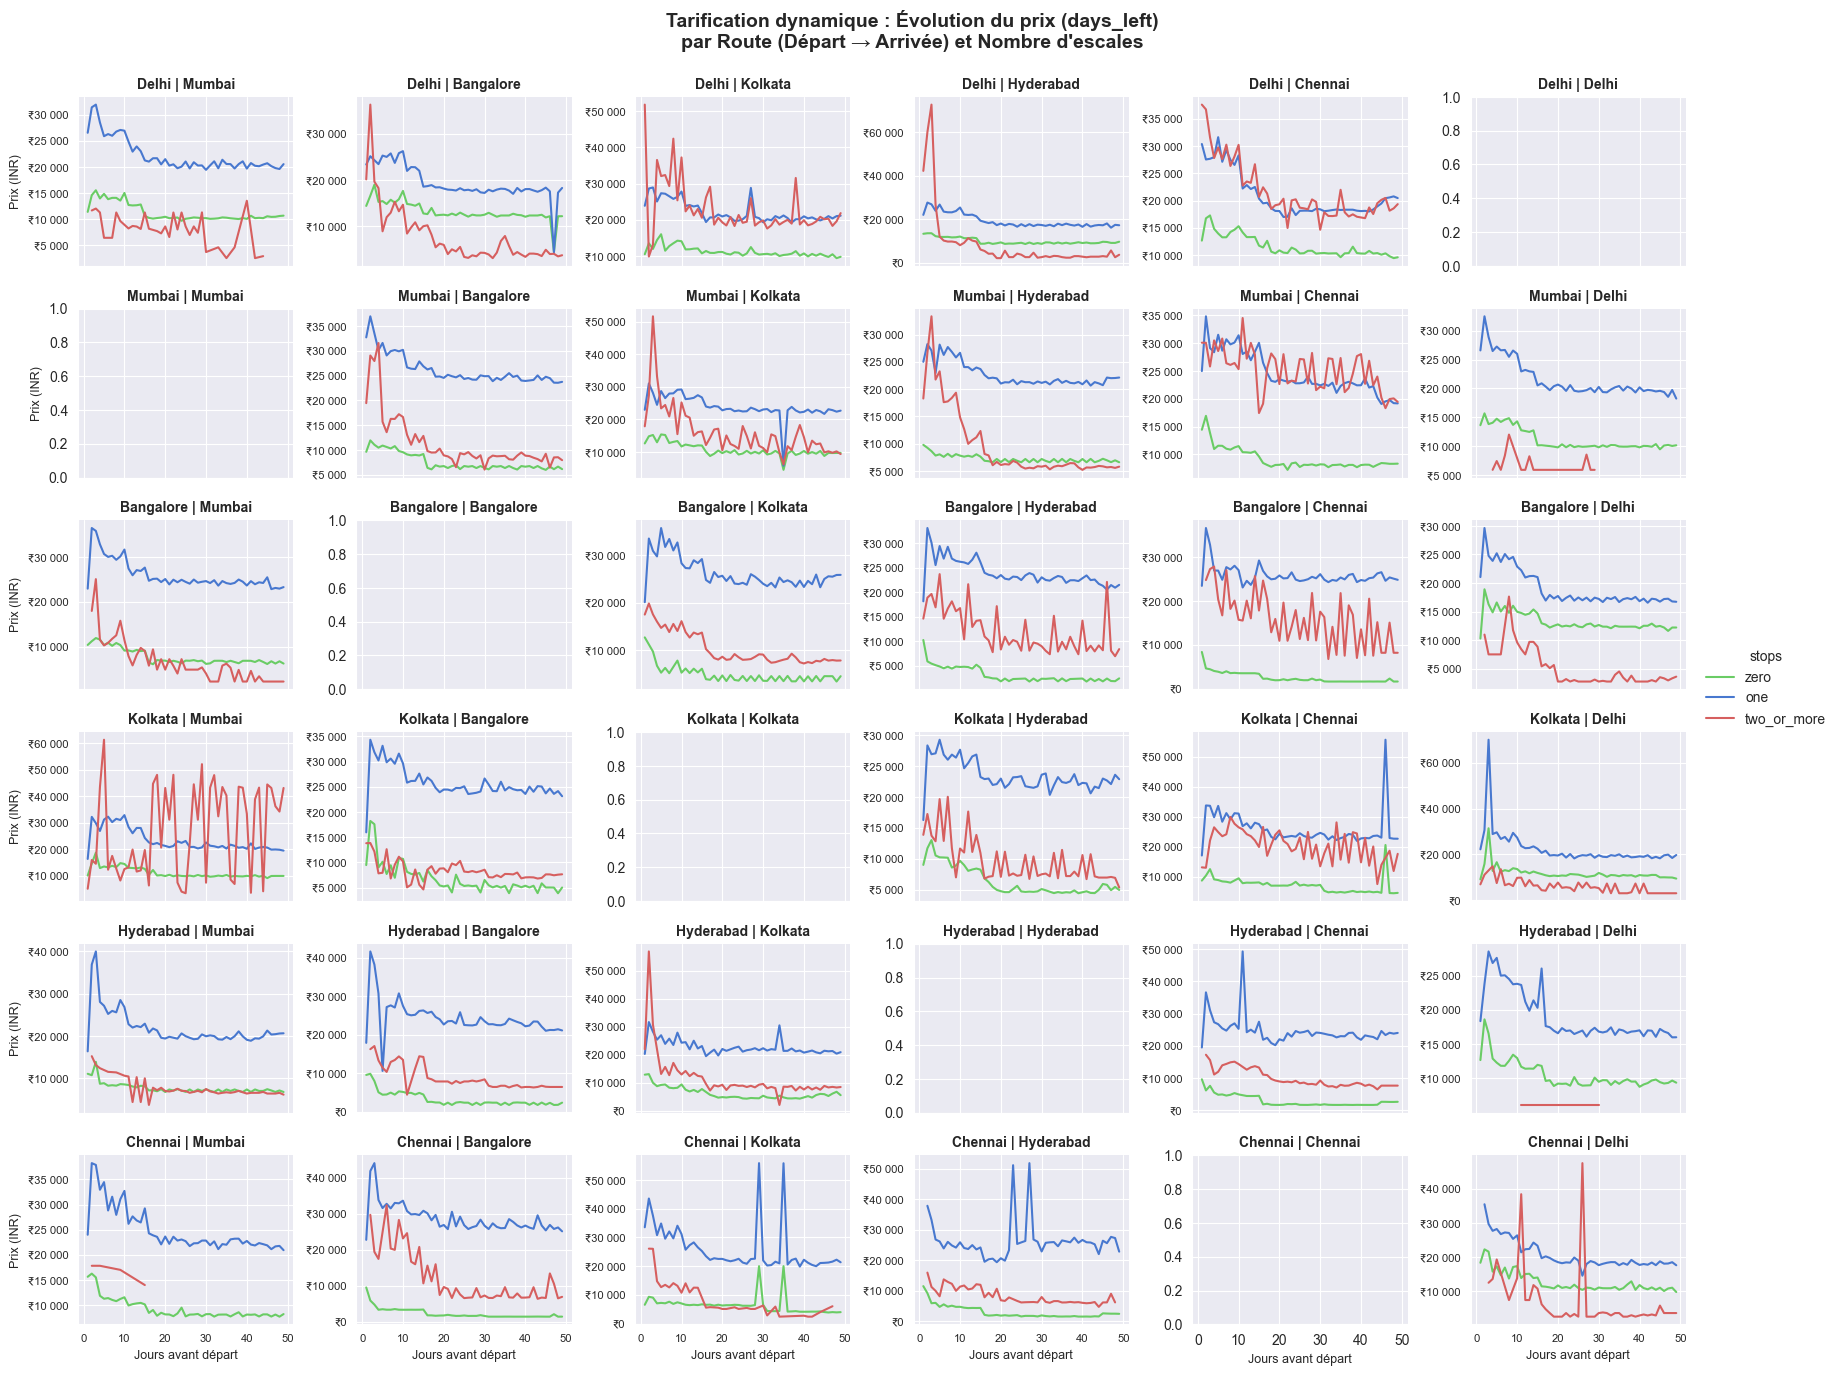

In [84]:
g = sns.relplot(
    data=clean_data,
    x="days_left",
    y="price",
    hue="stops",
    hue_order=["zero", "one", "two_or_more"],
    palette={"zero": "#6ACC65", "one": "#4878CF", "two_or_more": "#D65F5F"}, # Vert, Bleu, Rouge
    kind="line",
    errorbar=None, # Supprime l'intervalle de confiance pour accélérer le calcul et épurer les courbes
    row="source_city",
    col="destination_city",
    height=2.2, # Taille de chaque sous-graphique
    aspect=1.3,
    facet_kws={"sharey": False, "sharex": True} # sharey=False est CRITIQUE car le prix moyen varie fortement selon les routes
)

# 2. Post-traitement esthétique des axes (Inversion X et formatage Y)
for ax in g.axes.flat:
    # On vérifie si le sous-graphique contient des données (évite les erreurs sur les cases vides)
    if ax.has_data():
        # Inversion de l'axe X : la gauche = dernière minute, la droite = à l'avance
        ax.invert_xaxis()
        # Formatage des roupies avec espace pour les milliers
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"₹{x:,.0f}".replace(",", " ")))
        ax.tick_params(labelsize=8)

# 3. Titre général et ajustements
g.fig.suptitle("Tarification dynamique : Évolution du prix (days_left)\npar Route (Départ → Arrivée) et Nombre d'escales",
              fontsize=14, fontweight='bold', y=1.04)

g.set_axis_labels("Jours avant départ", "Prix (INR)", fontsize=9)
g.set_titles(row_template="{row_name}", col_template="{col_name}", fontweight='bold')

plt.show()

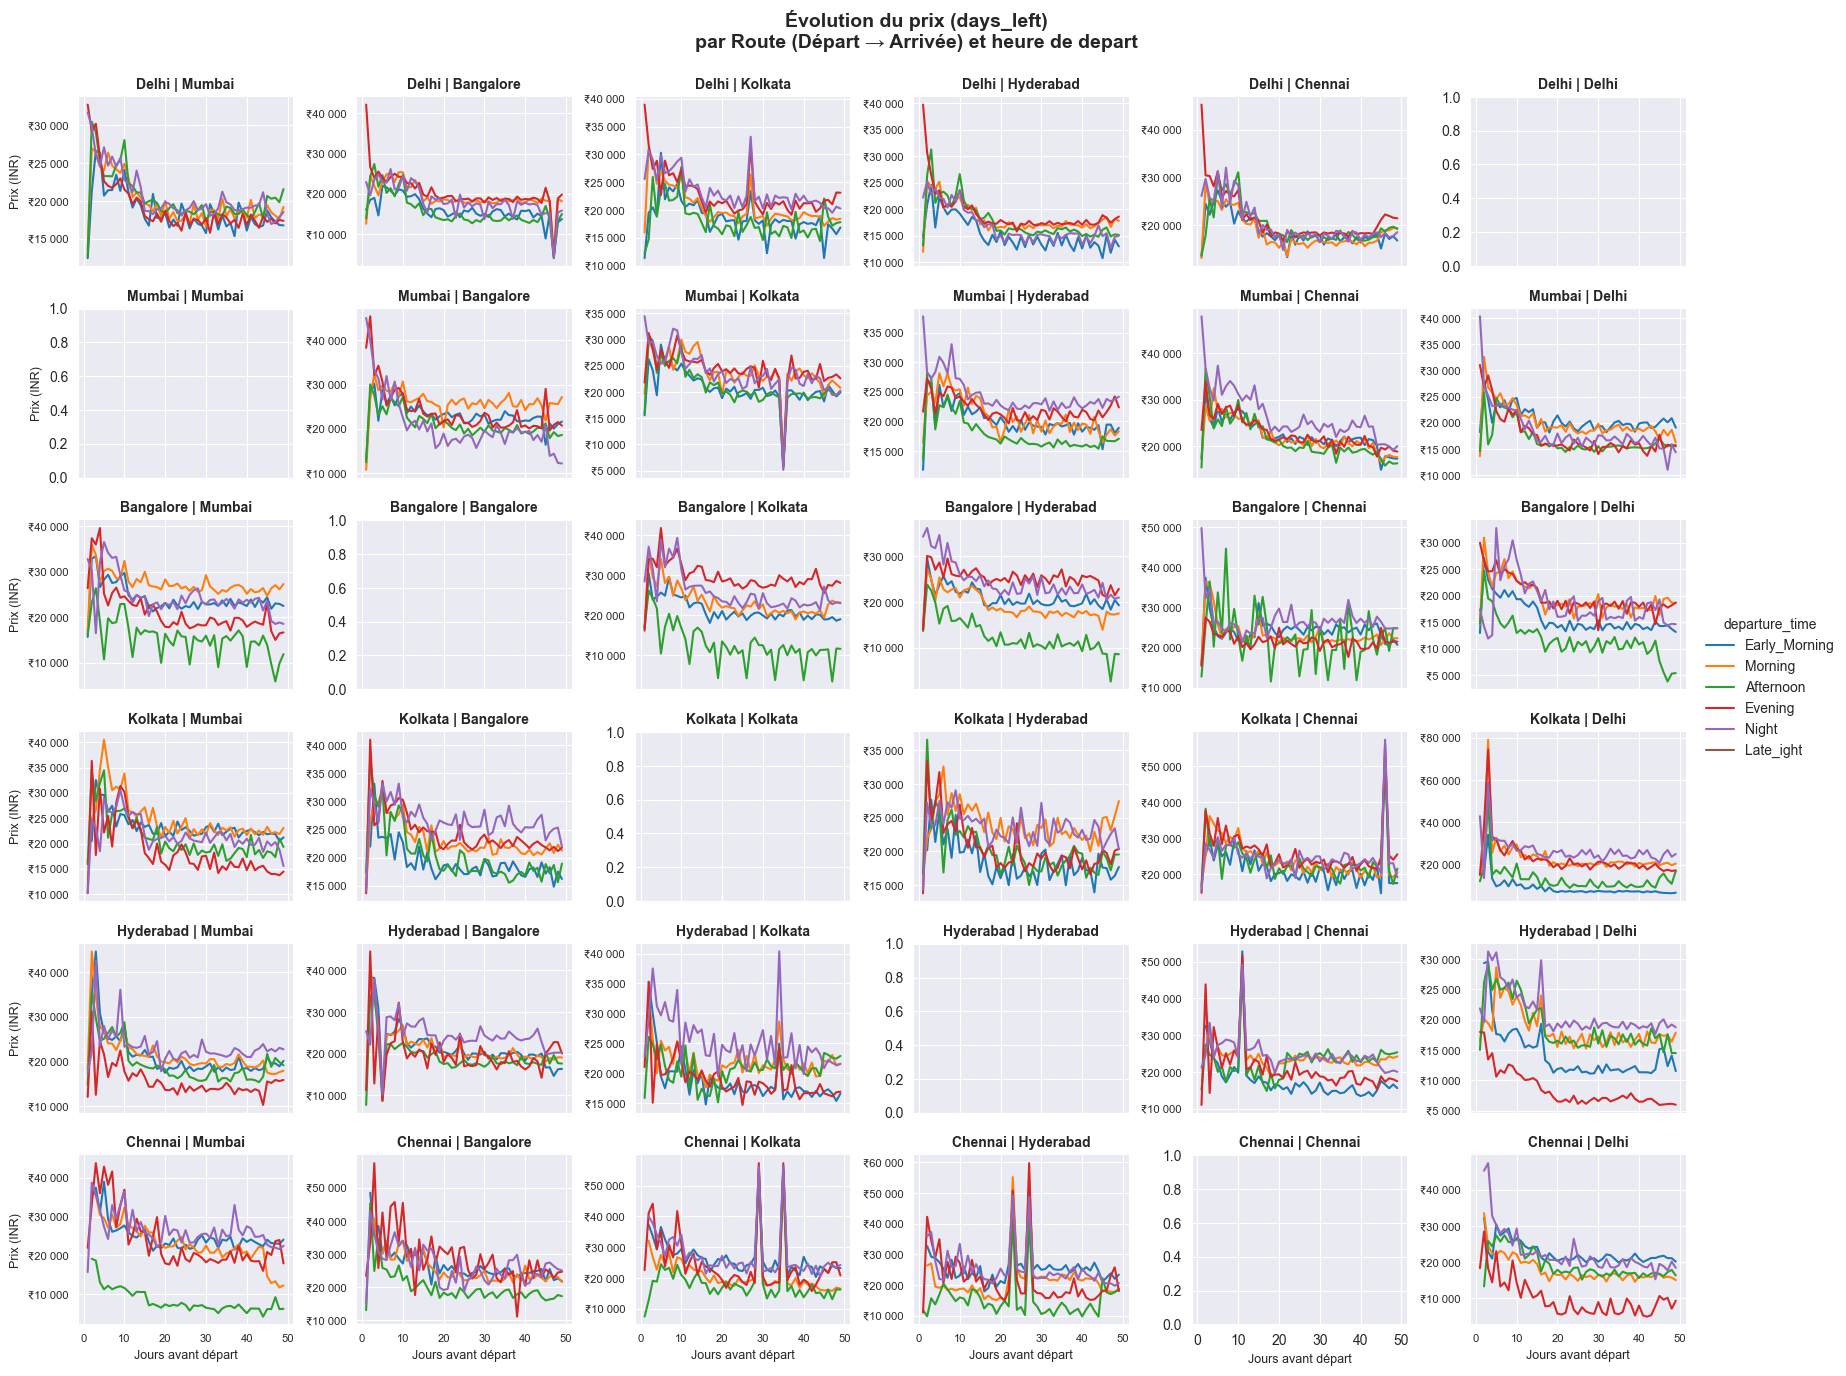

In [93]:
g = sns.relplot(
    data=clean_data,
    x="days_left",
    y="price",
    hue="departure_time",
    hue_order=["Early_Morning", "Morning", "Afternoon", "Evening", "Night", "Late_ight"],
    kind="line",
    errorbar=None, # Supprime l'intervalle de confiance pour accélérer le calcul et épurer les courbes
    row="source_city",
    col="destination_city",
    height=2.2, # Taille de chaque sous-graphique
    aspect=1.3,
    facet_kws={"sharey": False, "sharex": True} # sharey=False est CRITIQUE car le prix moyen varie fortement selon les routes
)

# 2. Post-traitement esthétique des axes (Inversion X et formatage Y)
for ax in g.axes.flat:
    # On vérifie si le sous-graphique contient des données (évite les erreurs sur les cases vides)
    if ax.has_data():
        # Inversion de l'axe X : la gauche = dernière minute, la droite = à l'avance
        ax.invert_xaxis()
        # Formatage des roupies avec espace pour les milliers
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"₹{x:,.0f}".replace(",", " ")))
        ax.tick_params(labelsize=8)

# 3. Titre général et ajustements
g.fig.suptitle("Évolution du prix (days_left)\npar Route (Départ → Arrivée) et heure de depart",
              fontsize=14, fontweight='bold', y=1.04)

g.set_axis_labels("Jours avant départ", "Prix (INR)", fontsize=9)
g.set_titles(row_template="{row_name}", col_template="{col_name}", fontweight='bold')

plt.show()